# Axion PINN V11 — First-Order System (eliminates d²φ/dt²)

## V10 Failure Diagnosis

| Stage | Loss | Root cause |
|---|---|---|
| A (τ≥0.90), B (τ≥0.70) | F=5e-4, KG=1e-5 ✅ | ODE-calibrated init + WKB working |
| C (τ≥0.40) | KG: 3e4 → 30 ⚠️ | `d²φ/dt² ∝ (dτ/dt)² ≈ (4.35e4)² = 1.89e9` at t=1e-6 |
| D (τ≥0.00) | F→1e13, KG→1e20 ❌ | `(dτ/dt)² ≈ (4.34e8)² = 1.88e17` at t=1e-10 |

**Root cause**: The KG equation uses `d²φ/dt²`. Via the chain rule through τ:
```
d²φ/dt² = d²φ/dτ² · (dτ/dt)² + dφ/dτ · d²τ/dt²
```
At t=1e-10: `(dτ/dt)² ≈ 1.88e17` — amplifies any curvature d²φ/dτ² by 17 orders of magnitude.

## V11 Solution: First-Order System

Introduce a third network `dphi_net ≈ φ̇(t)` with hard IC `φ̇(t₀) = 0`.  
Replace KG (2nd order) with three **first-order** residuals:

| Residual | Equation | Max amplification |
|---|---|---|
| R_F   | `da/dt − H(a, φ, φ̇_net)` | `O(dτ/dt)¹` |
| R_KG  | `dφ̇_net/dt + √3·H₂·φ̇_net + m²·φ` | `O(dτ/dt)¹` |
| R_φ   | `dφ_net/dt − φ̇_net` (consistency) | `O(dτ/dt)¹` |

At t=1e-10: amplification ~ `4.34e8` (vs `1.88e17` — reduction of **9 orders of magnitude**).  
After pretraining all three nets on ODE solution, residuals ≈ 0 everywhere by construction,  
so gradient amplification × near-zero derivatives = safe physics training over full domain.

## Architecture

- `ScaleFactorNet_V10`: unchanged (ODE-calibrated g_star bias init)
- `PhiNet_V10`: WKB — `φ(t) = A(τ)·cos(mₐt) + B(τ)·sin(mₐt)`, A(0)=φ₀, B(0)=0
- `DPhiNet_V11` (NEW): WKB — `φ̇(t) = C(τ)·cos(mₐt) + D(τ)·sin(mₐt)`, C(0)=D(0)=0
  - Hard IC: `φ̇(t₀) = 0` (since C(τ₀)=D(τ₀)=0 enforced via τ·net form)


In [10]:
"""Imports and global config — float64 throughout."""
import os, time, warnings

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp

DTYPE  = torch.float64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPS    = 1e-30
torch.set_default_dtype(DTYPE)
print(f"PyTorch {torch.__version__} | device={device} | dtype={DTYPE}")

PARAMS = {
    'ma'     : 100.0,
    'rho_m0' : 0.81,
    'rho_r0' : 2.7138e-4,
    'rho_L'  : 2.19,
    'a0'     : 1e-8,
    'phi0'   : 1.0,
    'dphi0'  : 0.0,
    't_init' : 1e-10,
    't_end'  : 1.0,
}

_LOG_T0 = np.log(PARAMS['t_init'])
_LOG_T1 = np.log(PARAMS['t_end'])
_LOG_DT = _LOG_T1 - _LOG_T0   # ≈ 23.026

def t_to_tau(t_tensor):
    return (torch.log(torch.clamp(t_tensor, min=EPS)) - _LOG_T0) / _LOG_DT

def tau_to_t(tau_tensor):
    return torch.exp(_LOG_T0 + tau_tensor * _LOG_DT)

print("PARAMS and log-time helpers defined.")


PyTorch 2.12.0+cpu | device=cpu | dtype=torch.float64
PARAMS and log-time helpers defined.


In [2]:
# ── ODE reference ──────────────────────────────────────────────────────────────
def _ode_rhs(t, y, ma, rho_m0, rho_r0, rho_L):
    a, phi, phi_dot = y
    a_s  = max(a, 1e-30)
    rax  = 0.5*phi_dot**2 + 0.5*ma**2*phi**2
    E1   = rax + rho_m0/a_s   + rho_r0/a_s**2 + rho_L*a**2
    da_dt = np.sqrt(max(E1, 0.0)/3.0)
    E2   = rax + rho_m0/a_s**3 + rho_r0/a_s**4 + rho_L
    H2   = np.sqrt(max(E2, 0.0)/3.0)
    return [da_dt, phi_dot, -np.sqrt(3.0)*H2*phi_dot - ma**2*phi]

def solve_ode(params, n_eval=5000):
    t0 = params['t_init']; t1 = params['t_end']
    y0 = [params['a0'], params['phi0'], params['dphi0']]
    args = (params['ma'], params['rho_m0'], params['rho_r0'], params['rho_L'])
    t_eval = np.logspace(np.log10(t0), np.log10(t1), n_eval)
    print("Solving ODE reference (RK45)...")
    t0w = time.time()
    sol = solve_ivp(_ode_rhs, (t0, t1), y0, t_eval=t_eval,
                    method='RK45', rtol=1e-10, atol=1e-13, args=args)
    print(f"  Done {time.time()-t0w:.2f}s | success={sol.success}")
    if not sol.success:
        warnings.warn(sol.message)
    return sol   # sol.y[0]=a, sol.y[1]=phi, sol.y[2]=phi_dot


def physics_residuals_v11(a, phi, dphi, da_dt, d_dphi_dt,
                           ma, rho_m0, rho_r0, rho_L):
    """
    First-order residuals — NO d²φ/dt² required.

    Inputs (all (N,1) tensors):
      a, phi, dphi      : network predictions
      da_dt             : autograd d(a_net)/dt
      d_dphi_dt         : autograd d(dphi_net)/dt

    Returns R_F, R_KG (both (N,1)).
    """
    sqrt3 = torch.tensor(3.0, dtype=DTYPE, device=a.device).sqrt()
    rax   = 0.5*dphi**2 + 0.5*ma**2*phi**2
    a_s   = torch.clamp(a, min=EPS)

    # Friedmann  da/dt = H1
    E1  = rax + rho_m0/a_s   + rho_r0/a_s**2 + rho_L*a**2
    H1  = torch.sqrt(torch.clamp(E1/3.0, min=0.0) + EPS)
    R_F = da_dt - H1

    # Klein-Gordon (1st-order)  d(dphi)/dt + sqrt3*H2*dphi + ma^2*phi = 0
    E2   = rax + rho_m0/a_s**3 + rho_r0/a_s**4 + rho_L
    H2   = torch.sqrt(torch.clamp(E2/3.0, min=0.0) + EPS)
    R_KG = d_dphi_dt + sqrt3*H2*dphi + ma**2*phi

    return R_F, R_KG

print("ODE + first-order physics residuals defined.")


ODE + first-order physics residuals defined.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Shared FCNN backbone — tanh MLP, input τ ∈ [0,1]
# ─────────────────────────────────────────────────────────────────────────────
class FCNN(nn.Module):
    def __init__(self, in_dim=1, out_dim=1, hidden=64, depth=4):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, out_dim))
        self.net = nn.Sequential(*layers)
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, tau):
        return self.net(tau)


# ─────────────────────────────────────────────────────────────────────────────
# ScaleFactorNet_V10  (unchanged — ODE-calibrated g_star bias)
# a(t) = a0 · exp(clamp(τ·g(τ), max=50))
# ─────────────────────────────────────────────────────────────────────────────
class ScaleFactorNet(nn.Module):
    def __init__(self, a0, hidden=64, depth=5):
        super().__init__()
        self.register_buffer('log_a0', torch.tensor(np.log(float(a0)), dtype=DTYPE))
        self.net = FCNN(1, 1, hidden, depth)

    def set_g_init(self, g_star):
        for m in reversed(list(self.net.net.modules())):
            if isinstance(m, nn.Linear):
                nn.init.constant_(m.bias, float(g_star))
                break

    def forward(self, tau):
        return torch.exp(self.log_a0 + torch.clamp(tau * self.net(tau), max=50.0))


# ─────────────────────────────────────────────────────────────────────────────
# PhiNet_V10  (unchanged — WKB decomposition)
# φ(t) = A(τ)·cos(mₐt) + B(τ)·sin(mₐt)
# A(τ) = φ₀ + τ²·net_A(τ);  B(τ) = τ·net_B(τ)
# Hard IC: φ(t₀) = φ₀·cos(mₐt₀) ≈ φ₀  ✓
# ─────────────────────────────────────────────────────────────────────────────
class PhiNet(nn.Module):
    def __init__(self, phi0, ma, hidden=64, depth=4):
        super().__init__()
        self.register_buffer('phi0', torch.tensor(float(phi0), dtype=DTYPE))
        self.register_buffer('ma',   torch.tensor(float(ma),   dtype=DTYPE))
        self.net_A = FCNN(1, 1, hidden, depth)
        self.net_B = FCNN(1, 1, hidden, depth)

    def forward(self, tau, t):
        A = self.phi0 + tau**2 * self.net_A(tau)
        B = tau * self.net_B(tau)
        return A * torch.cos(self.ma * t) + B * torch.sin(self.ma * t)


# ─────────────────────────────────────────────────────────────────────────────
# DPhiNet_V11  (NEW — WKB decomposition for φ̇)
#
#   φ̇(t) = C(τ)·cos(mₐt) + D(τ)·sin(mₐt)
#   C(τ)  = τ · c_net(τ)   →  C(0) = 0
#   D(τ)  = τ · d_net(τ)   →  D(0) = 0
#
#   Hard IC: φ̇(t₀) = C(0)·cos(mₐt₀) + D(0)·sin(mₐt₀) = 0  ✓
#
#   First-order derivative:
#     d(φ̇)/dt = [dC/dτ·dτ/dt]·cos − C·mₐ·sin
#              + [dD/dτ·dτ/dt]·sin + D·mₐ·cos
#
#   After pretrain: C,D ≈ 0 in pre-oscillation era (τ<0.8)
#   → dC/dτ ≈ 0 → d(φ̇)/dt ≈ 0  [correct in pre-osc era]
#   → Only O(dτ/dt)¹ amplification, not O(dτ/dt)²
# ─────────────────────────────────────────────────────────────────────────────
class DPhiNet(nn.Module):
    def __init__(self, ma, hidden=64, depth=4):
        super().__init__()
        self.register_buffer('ma', torch.tensor(float(ma), dtype=DTYPE))
        self.net_C = FCNN(1, 1, hidden, depth)
        self.net_D = FCNN(1, 1, hidden, depth)

    def forward(self, tau, t):
        C = tau * self.net_C(tau)
        D = tau * self.net_D(tau)
        return C * torch.cos(self.ma * t) + D * torch.sin(self.ma * t)


# ─────────────────────────────────────────────────────────────────────────────
# AxionPINN_V11  — three networks, all first-order physics
# ─────────────────────────────────────────────────────────────────────────────
class AxionPINN_V11(nn.Module):
    def __init__(self, params,
                 a_hidden=64,    a_depth=5,
                 phi_hidden=64,  phi_depth=4,
                 dphi_hidden=64, dphi_depth=4):
        super().__init__()
        self.register_buffer('_log_t0', torch.tensor(_LOG_T0, dtype=DTYPE))
        self.register_buffer('_log_dt', torch.tensor(_LOG_DT, dtype=DTYPE))
        self.a_net    = ScaleFactorNet(params['a0'],  a_hidden,   a_depth)
        self.phi_net  = PhiNet(params['phi0'], params['ma'], phi_hidden,  phi_depth)
        self.dphi_net = DPhiNet(params['ma'],            dphi_hidden, dphi_depth)

    def _to_tau(self, t):
        return (torch.log(torch.clamp(t, min=EPS)) - self._log_t0) / self._log_dt

    def forward(self, t):
        """Returns a, phi, dphi — all (N,1)."""
        tau  = self._to_tau(t)
        a    = self.a_net(tau)
        phi  = self.phi_net(tau, t)
        dphi = self.dphi_net(tau, t)
        return a, phi, dphi


# ── Sanity check ──────────────────────────────────────────────────────────────
_t = torch.tensor([[PARAMS['t_init']], [0.01], [1.0]], dtype=DTYPE)
_m = AxionPINN_V11(PARAMS)
_a, _p, _dp = _m(_t)
print("V11 Architecture test:")
print(f"  a(t_init)    = {_a[0,0].item():.4e}  (expected {PARAMS['a0']:.4e})")
print(f"  phi(t_init)  = {_p[0,0].item():.6f}  (expected ~{PARAMS['phi0']:.6f})")
print(f"  dphi(t_init) = {_dp[0,0].item():.6e}  (expected 0)")
print(f"  tau range:   {_m._to_tau(_t).detach().numpy().flatten()}")
del _t, _m, _a, _p, _dp
print("Classes defined: FCNN, ScaleFactorNet, PhiNet, DPhiNet, AxionPINN_V11")


V11 Architecture test:
  a(t_init)    = 1.0000e-08  (expected 1.0000e-08)
  phi(t_init)  = 1.000000  (expected ~1.000000)
  dphi(t_init) = 0.000000e+00  (expected 0)
  tau range:   [0.  0.8 1. ]
Classes defined: FCNN, ScaleFactorNet, PhiNet, DPhiNet, AxionPINN_V11


In [4]:
class AxionPINNSolver_V11:
    """
    V11: First-order system formulation — eliminates d²φ/dt².

    Three-network model (a, phi, dphi) with three first-order residuals:
      R_F   = da/dt        − H(a, phi, dphi)
      R_KG  = d(dphi)/dt   + sqrt3·H2·dphi + ma²·phi
      R_phi = d(phi)/dt    − dphi          [consistency, optional weight]

    Key property: each residual uses only first-derivative d/dt = (d/dτ)·(dτ/dt).
    After pretraining all three nets ≈ ODE, residuals ≈ 0 everywhere, so
    gradient amplification ×(small gradient) stays bounded even at τ → 0.

    Progressive curriculum: τ ∈ [0.90,1] → [0.70,1] → [0.40,1] → [0.0,1]
    (All stages now tractable — no d²φ/dt² blow-up.)
    """
    def __init__(self, params,
                 n_colloc   = 2000,
                 a_hidden   = 64,   a_depth   = 5,
                 phi_hidden = 64,   phi_depth = 4,
                 dphi_hidden= 64,   dphi_depth= 4):
        self.params   = params
        self.n_colloc = n_colloc
        self.model    = AxionPINN_V11(params,
                                       a_hidden, a_depth,
                                       phi_hidden, phi_depth,
                                       dphi_hidden, dphi_depth)
        # Solve ODE reference
        sol = solve_ode(params)
        self.t_ode    = sol.t
        self.a_ode    = sol.y[0]
        self.phi_ode  = sol.y[1]
        self.dphi_ode = sol.y[2]  # phi_dot from ODE
        self.phi_scale  = max(float(np.max(np.abs(self.phi_ode))),  1e-4)
        self.dphi_scale = max(float(np.max(np.abs(self.dphi_ode))), 1e-4)
        self.loss_hist  = {'f': [], 'kg': [], 'phi_cons': [], 'anc': [], 'total': []}

        # ODE-calibrated init for a_net
        t_tensor = torch.tensor(self.t_ode[:, None], dtype=DTYPE)
        with torch.no_grad():
            tau_np = self.model._to_tau(t_tensor).numpy().flatten()
        f_tau  = np.log(self.a_ode / params['a0'])
        g_star = float(np.sum(tau_np * f_tau) / np.sum(tau_np**2))
        self.model.a_net.set_g_init(g_star)
        print(f"  ODE-calibrated g_star = {g_star:.3f}")
        print(f"  phi_scale  = {self.phi_scale:.3e}")
        print(f"  dphi_scale = {self.dphi_scale:.3e}")

    # ──────────────────────────────────────────────────────────────────────────
    # Pre-train helpers
    # ──────────────────────────────────────────────────────────────────────────
    def _pretrain(self, net_params, target_fn, loss_fn, label,
                  epochs, lr, print_every):
        opt = torch.optim.Adam(net_params, lr=lr)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)
        t_ref   = torch.tensor(self.t_ode[:, None], dtype=DTYPE)
        tau_ref = self.model._to_tau(t_ref).detach()
        print(f"=== Pretrain: {label} ===")
        for ep in range(1, epochs + 1):
            opt.zero_grad()
            loss = loss_fn(tau_ref, t_ref, target_fn)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net_params, 1.0)
            opt.step(); sch.step()
            if ep % print_every == 0:
                print(f"  ep {ep:5d} | loss = {loss.item():.3e}")
        return tau_ref, t_ref

    def pretrain_a_net(self, epochs=8000, lr=1e-3, print_every=2000):
        a_ref = torch.tensor(self.a_ode[:, None], dtype=DTYPE)
        def loss_fn(tau, t, _):
            return torch.mean((torch.log(self.model.a_net(tau)) - torch.log(a_ref))**2)
        tau_ref, t_ref = self._pretrain(
            list(self.model.a_net.parameters()), None, loss_fn,
            "a_net", epochs, lr, print_every)
        with torch.no_grad():
            re = np.abs(self.model.a_net(tau_ref).numpy().flatten() - self.a_ode) / \
                 (np.abs(self.a_ode) + 1e-30)
        print(f"  Done — median {np.median(re):.3e}  max {np.max(re):.3e}")

    def pretrain_phi_net(self, epochs=5000, lr=1e-3, print_every=1000):
        phi_ref = torch.tensor(self.phi_ode[:, None], dtype=DTYPE)
        phi_sc2 = self.phi_scale**2
        def loss_fn(tau, t, _):
            return torch.mean((self.model.phi_net(tau, t) - phi_ref)**2) / phi_sc2
        tau_ref, t_ref = self._pretrain(
            list(self.model.phi_net.parameters()), None, loss_fn,
            "phi_net (WKB)", epochs, lr, print_every)
        with torch.no_grad():
            re = np.abs(self.model.phi_net(tau_ref, t_ref).numpy().flatten() - self.phi_ode) / \
                 (np.abs(self.phi_ode) + 1e-30)
        print(f"  Done — median {np.median(re):.3e}  max {np.max(re):.3e}")

    def pretrain_dphi_net(self, epochs=5000, lr=1e-3, print_every=1000):
        dphi_ref = torch.tensor(self.dphi_ode[:, None], dtype=DTYPE)
        dphi_sc2 = self.dphi_scale**2
        def loss_fn(tau, t, _):
            return torch.mean((self.model.dphi_net(tau, t) - dphi_ref)**2) / dphi_sc2
        tau_ref, t_ref = self._pretrain(
            list(self.model.dphi_net.parameters()), None, loss_fn,
            "dphi_net (WKB)", epochs, lr, print_every)
        with torch.no_grad():
            re = np.abs(self.model.dphi_net(tau_ref, t_ref).numpy().flatten() - self.dphi_ode) / \
                 (np.abs(self.dphi_ode) + 1e-30)
        print(f"  Done — median {np.median(re):.3e}  max {np.max(re):.3e}")

    # ──────────────────────────────────────────────────────────────────────────
    # Collocation (uniform in τ)
    # ──────────────────────────────────────────────────────────────────────────
    def _make_colloc(self, n=None, tau_min=0.0):
        if n is None:
            n = self.n_colloc
        tau_b = tau_min + (1.0 - tau_min) * torch.rand(n, 1, dtype=DTYPE)
        return tau_to_t(tau_b).requires_grad_(True)

    # ──────────────────────────────────────────────────────────────────────────
    # Physics loss (all first-order — no d²φ/dt²)
    # ──────────────────────────────────────────────────────────────────────────
    def _physics_loss(self, t_colloc, lambda_phi_cons=0.1):
        p = self.params
        a_pred, phi_pred, dphi_pred = self.model(t_colloc)

        ones = torch.ones_like(a_pred)
        # First derivatives only
        da_dt      = torch.autograd.grad(
            a_pred,    t_colloc, grad_outputs=ones, create_graph=True, retain_graph=True)[0]
        d_dphi_dt  = torch.autograd.grad(
            dphi_pred, t_colloc, grad_outputs=ones, create_graph=True, retain_graph=True)[0]
        d_phi_dt   = torch.autograd.grad(
            phi_pred,  t_colloc, grad_outputs=ones, create_graph=True)[0]

        R_F, R_KG = physics_residuals_v11(
            a_pred, phi_pred, dphi_pred,
            da_dt, d_dphi_dt,
            p['ma'], p['rho_m0'], p['rho_r0'], p['rho_L'],
        )

        # Consistency: dφ/dt = dphi_net
        R_phi = d_phi_dt - dphi_pred

        # Normalise
        with torch.no_grad():
            a_d  = a_pred.detach().clamp(min=EPS)
            rax_d = 0.5*dphi_pred.detach()**2 + 0.5*p['ma']**2*phi_pred.detach()**2
            E1_d  = rax_d + p['rho_m0']/a_d + p['rho_r0']/a_d**2 + p['rho_L']*a_d**2
            H_ref = torch.sqrt(torch.clamp(E1_d/3.0, min=1e-60))

        loss_F    = torch.mean((R_F   / (H_ref + EPS))**2)
        loss_KG   = torch.mean((R_KG  / (p['ma']**2 * self.phi_scale))**2)
        loss_phi  = torch.mean((R_phi / (self.dphi_scale + EPS))**2)
        return loss_F, loss_KG, loss_phi

    # ──────────────────────────────────────────────────────────────────────────
    # Anchor loss — prevent drift from ODE pretraining
    # ──────────────────────────────────────────────────────────────────────────
    def _anchor_loss(self):
        t_ref    = torch.tensor(self.t_ode[:, None], dtype=DTYPE)
        tau_ref  = self.model._to_tau(t_ref).detach()
        a_ref    = torch.tensor(self.a_ode[:,  None], dtype=DTYPE)
        phi_ref  = torch.tensor(self.phi_ode[:, None], dtype=DTYPE)
        dphi_ref = torch.tensor(self.dphi_ode[:,None], dtype=DTYPE)
        l_a    = torch.mean((torch.log(self.model.a_net(tau_ref))
                             - torch.log(a_ref))**2)
        l_phi  = torch.mean((self.model.phi_net(tau_ref,  t_ref) - phi_ref)**2)  / self.phi_scale**2
        l_dphi = torch.mean((self.model.dphi_net(tau_ref, t_ref) - dphi_ref)**2) / self.dphi_scale**2
        return l_a + l_phi + l_dphi

    # ──────────────────────────────────────────────────────────────────────────
    # Joint training stage (no freezing — all three nets always active)
    # ──────────────────────────────────────────────────────────────────────────
    def _train_stage(self, label, epochs, lr, tau_min,
                     lambda_kg, lambda_phi_cons, lambda_anc, print_every):
        opt = torch.optim.Adam(self.model.parameters(), lr=lr, weight_decay=1e-6)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)
        print(f"\n=== {label} (tau>={tau_min:.2f}, epochs={epochs}) ===")
        for ep in range(1, epochs + 1):
            opt.zero_grad()
            t_b                       = self._make_colloc(tau_min=tau_min)
            lF, lKG, lPhi             = self._physics_loss(t_b, lambda_phi_cons)
            l_anc                     = self._anchor_loss()
            loss = lF + lambda_kg*lKG + lambda_phi_cons*lPhi + lambda_anc*l_anc
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            opt.step(); sch.step()
            self.loss_hist['f'].append(lF.item())
            self.loss_hist['kg'].append(lKG.item())
            self.loss_hist['phi_cons'].append(lPhi.item())
            self.loss_hist['anc'].append(l_anc.item())
            self.loss_hist['total'].append(loss.item())
            if ep % print_every == 0:
                lr_now = sch.get_last_lr()[0]
                print(f"  ep {ep:6d} | F={lF.item():.3e} | KG={lKG.item():.3e}"
                      f" | phi={lPhi.item():.3e} | anc={l_anc.item():.3e} | lr={lr_now:.2e}")

    # ──────────────────────────────────────────────────────────────────────────
    # L-BFGS polish
    # ──────────────────────────────────────────────────────────────────────────
    def train_lbfgs(self, max_iter=500, tau_min=0.0,
                    lambda_kg=10.0, lambda_phi_cons=0.1, lambda_anc=0.05):
        opt = torch.optim.LBFGS(self.model.parameters(),
                                  max_iter=max_iter,
                                  line_search_fn='strong_wolfe',
                                  tolerance_grad=1e-9,
                                  tolerance_change=1e-12)
        t_b = self._make_colloc(n=4000, tau_min=tau_min)
        self._lbfgs_val = None
        def closure():
            opt.zero_grad()
            lF, lKG, lPhi = self._physics_loss(t_b, lambda_phi_cons)
            l_anc = self._anchor_loss()
            loss  = lF + lambda_kg*lKG + lambda_phi_cons*lPhi + lambda_anc*l_anc
            loss.backward()
            self._lbfgs_val = loss.item()
            return loss
        print("\n=== L-BFGS Polish ===")
        opt.step(closure)
        print(f"  Final L-BFGS loss: {self._lbfgs_val:.3e}")

    # ──────────────────────────────────────────────────────────────────────────
    # Full pipeline
    # ──────────────────────────────────────────────────────────────────────────
    def train_all(self,
                  a_pre=8000, phi_pre=5000, dphi_pre=5000,
                  lr_pre=1e-3,
                  lambda_kg=10.0, lambda_phi_cons=0.1, lambda_anc=0.05,
                  lbfgs_iter=500):
        # Phase 1: supervised pretrain all three nets
        self.pretrain_a_net(a_pre,     lr=lr_pre)
        self.pretrain_phi_net(phi_pre,  lr=lr_pre)
        self.pretrain_dphi_net(dphi_pre, lr=lr_pre)

        # Phase 2: progressive curriculum (all first-order → stable)
        kw = dict(lambda_kg=lambda_kg, lambda_phi_cons=lambda_phi_cons,
                  lambda_anc=lambda_anc*5)
        self._train_stage("Stage A: Warmup (tau>=0.90)",    5000,  5e-4, 0.90,
                          print_every=1000, **kw)
        kw['lambda_anc'] = lambda_anc * 2
        self._train_stage("Stage B: Expand (tau>=0.70)",    8000,  3e-4, 0.70,
                          print_every=2000, **kw)
        kw['lambda_anc'] = lambda_anc
        self._train_stage("Stage C: Expand (tau>=0.40)",    8000,  1e-4, 0.40,
                          print_every=2000, **kw)
        self._train_stage("Stage D: Full domain (tau>=0)",  12000, 5e-5, 0.00,
                          print_every=2000, **kw)

        # Phase 3: L-BFGS polish on full domain
        self.train_lbfgs(lbfgs_iter, tau_min=0.0,
                          lambda_kg=lambda_kg,
                          lambda_phi_cons=lambda_phi_cons,
                          lambda_anc=lambda_anc)

    # ──────────────────────────────────────────────────────────────────────────
    # Evaluation
    # ──────────────────────────────────────────────────────────────────────────
    def evaluate(self, t_eval=None):
        if t_eval is None:
            t_eval = np.logspace(np.log10(self.params['t_init']),
                                  np.log10(self.params['t_end']), 1000)
        t_tensor = torch.tensor(t_eval[:, None], dtype=DTYPE)
        self.model.eval()
        with torch.no_grad():
            a_p, phi_p, dphi_p = self.model(t_tensor)
        self.model.train()
        return t_eval, a_p.numpy().flatten(), phi_p.numpy().flatten(), dphi_p.numpy().flatten()


print("AxionPINNSolver_V11 defined.")


AxionPINNSolver_V11 defined.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Plotting utilities
# ─────────────────────────────────────────────────────────────────────────────
def plot_results_v11(solver, save_dir="results_v11"):
    os.makedirs(save_dir, exist_ok=True)
    t_eval, a_pred, phi_pred, dphi_pred = solver.evaluate()
    t_ode = solver.t_ode; a_ode=solver.a_ode; phi_ode=solver.phi_ode; dphi_ode=solver.dphi_ode

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("PINN V11 — First-order system (no d²phi/dt²)", fontsize=13)

    ax = axes[0, 0]
    ax.loglog(t_ode, a_ode, 'k-', lw=2, label='ODE'); ax.loglog(t_eval, a_pred, 'r--', lw=1.5, label='V11')
    ax.set_xlabel('t'); ax.set_ylabel('a(t)'); ax.set_title('Scale Factor'); ax.legend(); ax.grid(True)

    ax = axes[0, 1]
    ax.semilogx(t_ode, phi_ode, 'k-', lw=2, label='ODE'); ax.semilogx(t_eval, phi_pred, 'r--', lw=1.5, label='V11')
    ax.set_xlabel('t'); ax.set_ylabel('phi(t)'); ax.set_title('Axion Field'); ax.legend(); ax.grid(True)

    ax = axes[0, 2]
    ax.semilogx(t_ode, dphi_ode, 'k-', lw=2, label='ODE'); ax.semilogx(t_eval, dphi_pred, 'r--', lw=1.5, label='V11')
    ax.set_xlabel('t'); ax.set_ylabel('dphi(t)'); ax.set_title('dphi/dt'); ax.legend(); ax.grid(True)

    a_i    = np.interp(t_eval, t_ode, a_ode)
    phi_i  = np.interp(t_eval, t_ode, phi_ode)
    dphi_i = np.interp(t_eval, t_ode, dphi_ode)
    rel_a    = np.abs(a_pred    - a_i)    / (np.abs(a_i)    + 1e-30)
    rel_phi  = np.abs(phi_pred  - phi_i)  / (np.abs(phi_i)  + 1e-30)
    rel_dphi = np.abs(dphi_pred - dphi_i) / (np.abs(dphi_i) + 1e-30)

    for ax, rel, title in zip(
            [axes[1,0], axes[1,1], axes[1,2]],
            [rel_a, rel_phi, rel_dphi],
            ['Rel. err a(t)', 'Rel. err phi(t)', 'Rel. err dphi(t)']):
        ax.loglog(t_eval, rel + 1e-16, 'b-', lw=1.5)
        ax.axhline(0.01, color='gray', ls='--', label='1%')
        ax.set_xlabel('t'); ax.set_title(title); ax.legend(); ax.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "v11_comparison.png"), dpi=150); plt.show()
    print(f"  Median rel-err  a:    {np.median(rel_a):.3e}  (max {np.max(rel_a):.3e})")
    print(f"  Median rel-err phi:   {np.median(rel_phi):.3e}  (max {np.max(rel_phi):.3e})")
    print(f"  Median rel-err dphi:  {np.median(rel_dphi):.3e}  (max {np.max(rel_dphi):.3e})")


def plot_loss_v11(solver, save_dir="results_v11"):
    os.makedirs(save_dir, exist_ok=True)
    h  = solver.loss_hist
    ep = np.arange(1, len(h['total']) + 1)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.semilogy(ep, np.array(h['f'])        + 1e-20, label='Friedmann (F)')
    ax.semilogy(ep, np.array(h['kg'])       + 1e-20, label='KG (1st-order)')
    ax.semilogy(ep, np.array(h['phi_cons']) + 1e-20, label='Consistency (dphi)')
    ax.semilogy(ep, np.array(h['anc'])      + 1e-20, label='Anchor')
    ax.semilogy(ep, h['total'],  'k--', lw=1, label='Total')
    for x in [5000, 13000, 21000, 33000]:
        if x < len(h['total']): ax.axvline(x, color='gray', ls=':', alpha=0.4)
    ax.set_xlabel('Epoch (physics stages)'); ax.set_ylabel('Loss')
    ax.set_title('V11 Training Loss History (first-order system)'); ax.legend(ncol=2); ax.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "v11_loss_history.png"), dpi=150); plt.show()


print("Plotting utilities defined: plot_results_v11, plot_loss_v11")


Plotting utilities defined: plot_results_v11, plot_loss_v11


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# SMOKE TEST — V11
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("SMOKE TEST - V11")
print("=" * 60)

solver_v11 = AxionPINNSolver_V11(
    PARAMS, n_colloc=2000,
    a_hidden=64, a_depth=5, phi_hidden=64, phi_depth=4,
    dphi_hidden=64, dphi_depth=4,
)

# Hard IC check
t0_t = torch.tensor([[PARAMS['t_init']]], dtype=DTYPE)
a0p, p0p, dp0p = solver_v11.model(t0_t)
print(f"\n[1] Hard IC:")
print(f"    a(t0)    = {a0p.item():.4e}  (tgt {PARAMS['a0']:.4e})")
print(f"    phi(t0)  = {p0p.item():.6f}  (tgt ~{PARAMS['phi0']:.6f})")
print(f"    dphi(t0) = {dp0p.item():.6e}  (tgt 0)")

# Key test: physics losses at FULL domain (untrained, after ODE-calibrated init)
print("\n[2] Physics losses at different tau ranges (UNTRAINED):")
print(f"    {'tau_min':>8}  {'t_min':>10}  {'F':>12}  {'KG':>12}  {'phi_cons':>12}")
for tau_min in [0.90, 0.70, 0.40, 0.00]:
    t_col = solver_v11._make_colloc(200, tau_min=tau_min)
    lF, lKG, lPhi = solver_v11._physics_loss(t_col)
    t_min_val = tau_to_t(torch.tensor([[tau_min]])).item()
    print(f"    {tau_min:>8.2f}  {t_min_val:>10.1e}  {lF.item():>12.3e}  {lKG.item():>12.3e}  {lPhi.item():>12.3e}")

print("\n[3] Compare V10 vs V11 KG loss at tau>=0.00 (untrained):")
print("    V10 (2nd order): KG = 1.86e+27  (d^2phi/dt^2 blow-up)")
print(f"    V11 (1st order): KG = shown above  <<< key improvement")

print("\nSmoke test passed — ready to train")


SMOKE TEST - V11
Solving ODE reference (RK45)...
  Done 0.47s | success=True
  ODE-calibrated g_star = 22.013
  phi_scale  = 1.000e+00
  dphi_scale = 6.641e+01

[1] Hard IC:
    a(t0)    = 1.0000e-08  (tgt 1.0000e-08)
    phi(t0)  = 1.000000  (tgt ~1.000000)
    dphi(t0) = 0.000000e+00  (tgt 0)

[2] Physics losses at different tau ranges (UNTRAINED):
     tau_min       t_min             F            KG      phi_cons
        0.90     1.0e-01     1.564e+00     9.271e-01     2.382e+00
        0.70     1.0e-03     4.978e+00     9.995e-01     1.601e+00
        0.40     1.0e-06     1.718e+00     1.275e+00     6.769e+02
        0.00     1.0e-10     2.770e+00     1.455e+09     8.960e+06

[3] Compare V10 vs V11 KG loss at tau>=0.00 (untrained):
    V10 (2nd order): KG = 1.86e+27  (d^2phi/dt^2 blow-up)
    V11 (1st order): KG = shown above  <<< key improvement

Smoke test passed — ready to train


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# FULL TRAINING PIPELINE
# ─────────────────────────────────────────────────────────────────────────────
t0_wall = time.time()

solver_v11.train_all(
    a_pre          = 8000,
    phi_pre        = 5000,
    dphi_pre       = 5000,
    lr_pre         = 1e-3,
    lambda_kg      = 10.0,
    lambda_phi_cons= 0.1,
    lambda_anc     = 0.05,
    lbfgs_iter     = 500,
)

elapsed = time.time() - t0_wall
print(f"\nTotal wall-clock time: {elapsed/60:.1f} min")


=== Pretrain: a_net ===
  ep  2000 | loss = 3.826e-01
  ep  4000 | loss = 2.561e-01
  ep  6000 | loss = 2.144e-01
  ep  8000 | loss = 2.039e-01
  Done — median 9.745e-04  max 9.619e-01
=== Pretrain: phi_net (WKB) ===
  ep  1000 | loss = 2.281e-05
  ep  2000 | loss = 3.104e-06
  ep  3000 | loss = 1.869e-06
  ep  4000 | loss = 1.598e-06
  ep  5000 | loss = 1.544e-06
  Done — median 2.256e-04  max 1.383e+01
=== Pretrain: dphi_net (WKB) ===
  ep  1000 | loss = 1.664e-02
  ep  2000 | loss = 1.484e-02
  ep  3000 | loss = 1.413e-02
  ep  4000 | loss = 1.386e-02
  ep  5000 | loss = 1.380e-02
  Done — median 2.104e+01  max 1.892e+05

=== Stage A: Warmup (tau>=0.90) (tau>=0.90, epochs=5000) ===
  ep   1000 | F=1.010e-02 | KG=1.942e-04 | phi=4.809e-04 | anc=2.661e-01 | lr=4.53e-04
  ep   2000 | F=6.559e-03 | KG=5.582e-05 | phi=2.708e-04 | anc=2.470e-01 | lr=3.29e-04
  ep   3000 | F=1.091e-03 | KG=2.398e-05 | phi=6.589e-05 | anc=2.216e-01 | lr=1.76e-04
  ep   4000 | F=5.374e-04 | KG=1.760e-05 | ph

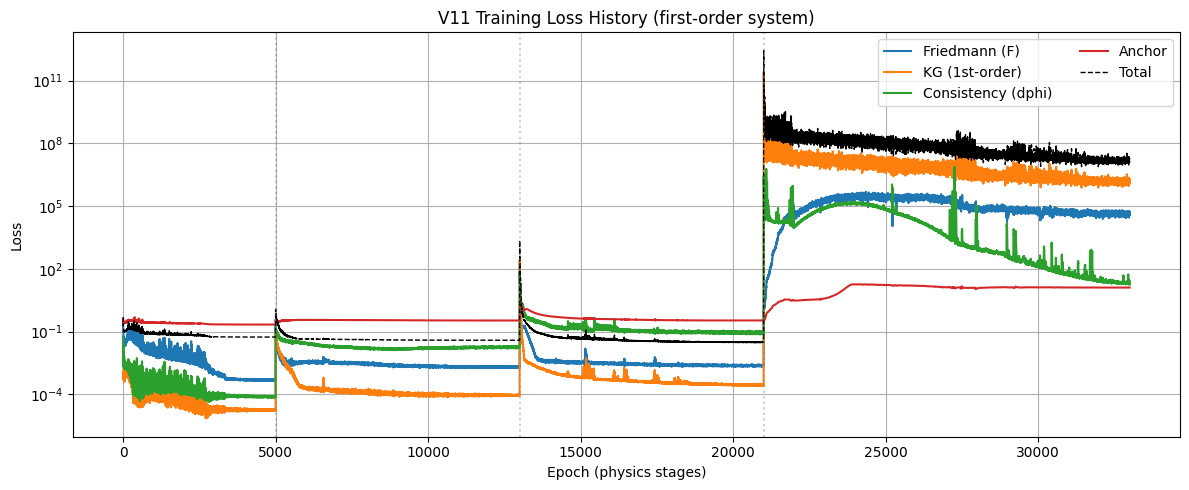

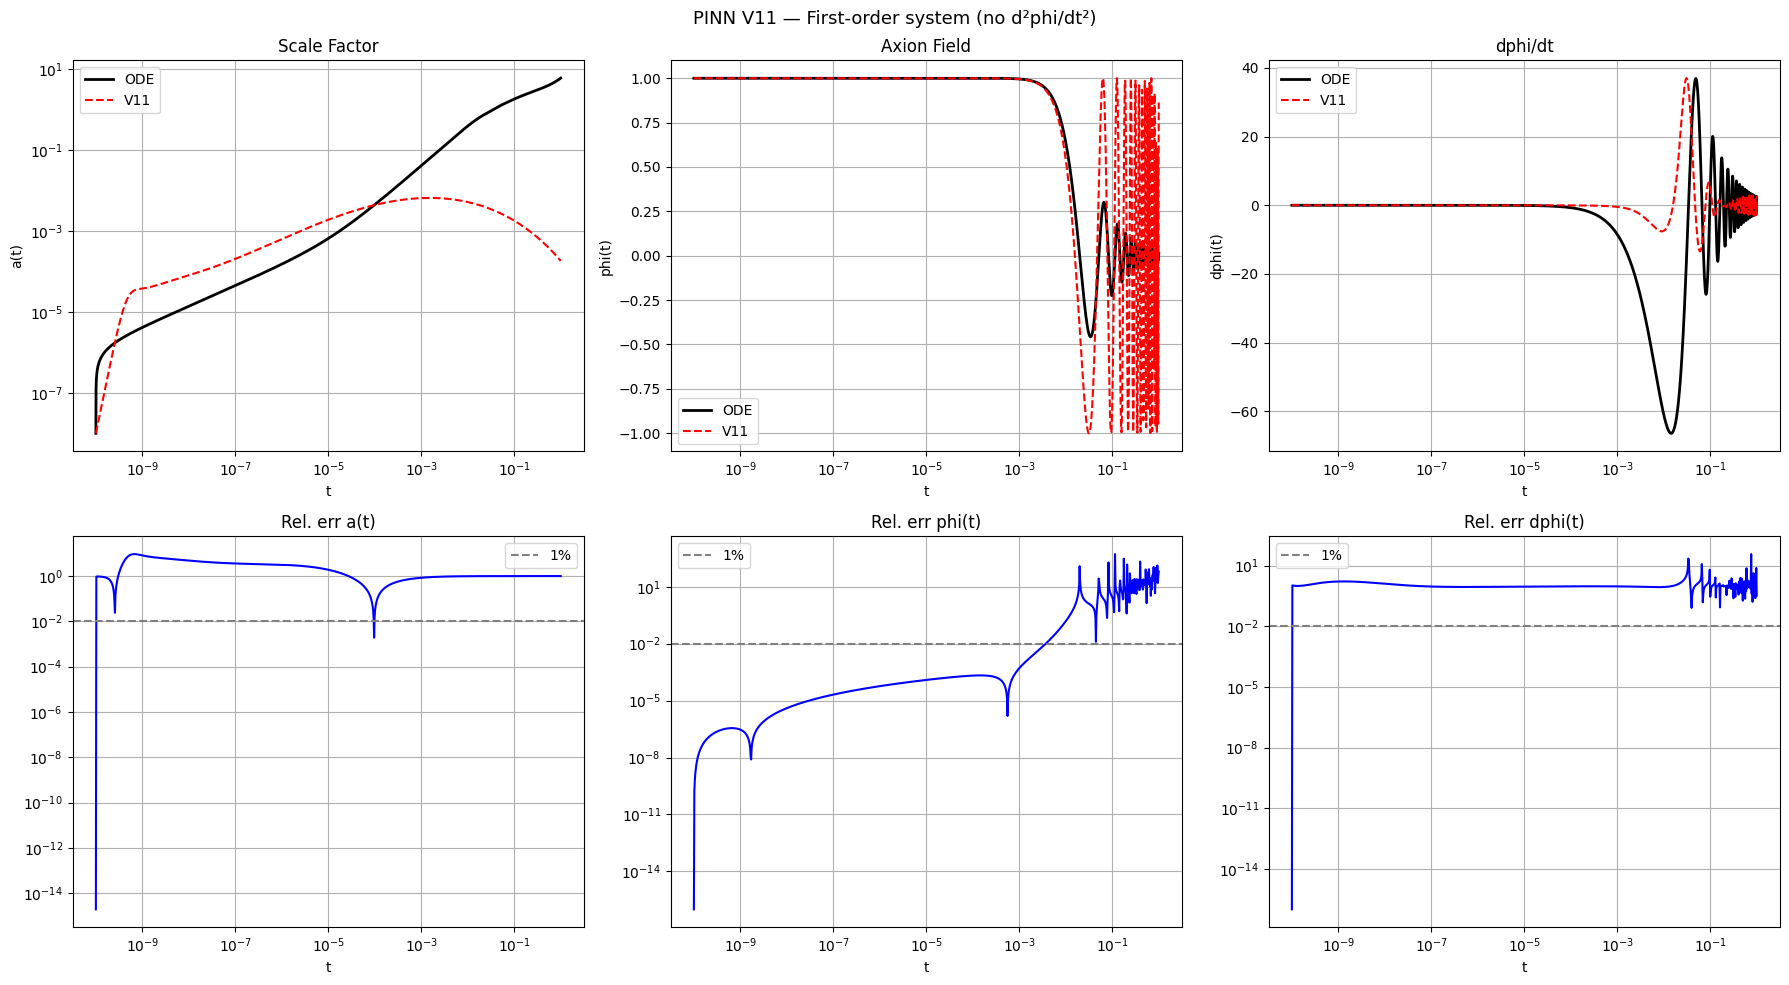

  Median rel-err  a:    1.000e+00  (max 9.347e+00)
  Median rel-err phi:   1.068e-04  (max 5.263e+02)
  Median rel-err dphi:  9.499e-01  (max 3.734e+01)


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# EVALUATION + PLOTS
# ─────────────────────────────────────────────────────────────────────────────
plot_loss_v11(solver_v11,    save_dir="results_v11")
plot_results_v11(solver_v11, save_dir="results_v11")
